# IoT-Driven Machine Learning Framework for Fraud Detection and Customer Risk Prediction in Retail Banking

---

## Task 01: Dataset Selection and Description

### Project Introduction

In this research, I aim to develop an IoT-Driven Machine Learning Framework for Fraud Detection and Customer Risk Prediction in Retail Banking. The banking sector has rapidly shifted toward digital platforms such as credit cards, personal loans, mobile banking, ATM transactions, internet banking, and online payments. While these advancements have improved customer convenience and operational efficiency, they have also increased the risk of financial fraud.

Traditional fraud detection systems used by banks are mostly rule-based, static, and reactive. These systems are often unable to detect modern fraud patterns such as unusual spending behavior, account takeover, identity theft, location spoofing, and unauthorized transactions happening across multiple digital channels.

The major research gap identified in previous studies is that most fraud detection models focus only on credit card fraud using historical datasets and offline analysis. Very limited research has been conducted on integrating IoT-generated real-time transaction data with machine learning models for fraud detection across multiple retail banking products.

This project aims to address that gap by developing a machine learning-based fraud detection system that can detect fraudulent transactions in real time, identify high-risk customers, reduce false positives and false negatives, and support better banking decisions using Management Information System (MIS) dashboards.

The machine learning models considered in this research include Logistic Regression, Random Forest, Gradient Boosting Machine, and Multilayer Perceptron for comparative performance analysis.

## Step 2: Dataset Selection and Source

### Dataset Name

Credit Card Fraud Detection Dataset

### Dataset Source (URL)

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

### Dataset Description

For this research, I selected the Credit Card Fraud Detection Dataset from Kaggle because it is one of the most widely used public datasets for fraud detection research.

This dataset contains real-world credit card transactions made by European cardholders in September 2013. It includes both legitimate and fraudulent transactions, which makes it highly suitable for binary classification problems in machine learning.

The dataset is highly imbalanced because fraudulent transactions are very few compared to normal transactions. This makes it a strong dataset for fraud detection research because real banking fraud problems also face the same challenge.

### Why I Selected This Dataset

I selected this dataset because:

- it is widely accepted in research papers
- it supports fraud detection classification tasks
- it contains real-world transaction behavior
- it is suitable for machine learning implementation
- it helps ensure research reproducibility
- it can be extended toward IoT-driven behavioral analysis

This makes it academically strong and easy to defend during viva.

In [1]:
# Install kagglehub library

!pip install kagglehub

In [2]:
# Import kagglehub

import kagglehub

# Download latest version of dataset

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [3]:
print(path)

/kaggle/input/creditcardfraud


## Step 3: Load Dataset and Verify Structure

After downloading the dataset, the next step is to load the CSV file into Google Colab and verify its structure.

In this step, I will:

- read the dataset using pandas
- display the first 5 rows
- check the total number of rows and columns
- confirm that the dataset is ready for preprocessing

This step helps ensure that the dataset has been downloaded successfully and is suitable for further analysis and model implementation.

In [4]:
# Import required library

import pandas as pd
import os

In [5]:
# Check files inside downloaded dataset folder

print("Files inside dataset folder:\n")
print(os.listdir(path))

Files inside dataset folder:

['creditcard.csv']


In [6]:
# Load the CSV file

df = pd.read_csv(path + "/creditcard.csv")

# Display first 5 rows

print("First 5 Rows of Dataset:\n")
print(df.head())

# Display dataset shape

print("\nDataset Shape:")
print(df.shape)

First 5 Rows of Dataset:

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

      

In [7]:
print(df.shape)

(284807, 31)


## Step 4: Dataset Description and Class Distribution

Before building machine learning models, it is necessary to understand the quality and structure of the dataset.

In this step, I will examine:

- total number of features
- column names
- data types
- missing values
- fraud and non-fraud transaction distribution

This step is especially important because fraud detection datasets are usually highly imbalanced, where fraudulent transactions are much fewer than normal transactions.

Understanding this imbalance helps in selecting proper preprocessing techniques such as SMOTE and improves model performance.

In [8]:
# Display all column names

print("Columns in Dataset:\n")
print(df.columns)

Columns in Dataset:

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [9]:
# Display data types of all columns

print("Data Types of Dataset:\n")
print(df.dtypes)

Data Types of Dataset:

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [10]:
# Check missing values

print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [11]:
# Check class distribution

print("Fraud vs Non-Fraud Distribution:\n")
print(df['Class'].value_counts())

Fraud vs Non-Fraud Distribution:

Class
0    284315
1       492
Name: count, dtype: int64


In [12]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


## Step 5: Data Preprocessing and Train-Test Split

Before training machine learning models, the dataset must be preprocessed to improve model performance and ensure reliable predictions.

In this step, I will perform:

- feature scaling
- separation of input features and target variable
- train-test split for model training and evaluation

The dataset contains highly imbalanced fraud cases, so proper preprocessing is necessary to avoid biased model predictions.

The target variable is:

Class

Where:

- 0 = Non-Fraud Transaction
- 1 = Fraudulent Transaction

The dataset will be divided using:

- 80% Training Data
- 20% Testing Data

This helps ensure proper model learning and fair evaluation on unseen data.

In [13]:
# Import required libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
# Separate input features (X) and target variable (y)

X = df.drop("Class", axis=1)
y = df["Class"]

print("Input Features Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Input Features Shape: (284807, 30)
Target Variable Shape: (284807,)


In [15]:
# Scale the Amount feature

scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])

print("Feature Scaling Completed")

Feature Scaling Completed


In [16]:
# Train-Test Split (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (227845, 30)
Testing Data Shape: (56962, 30)


In [17]:
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


## Step 6: Handling Class Imbalance Using SMOTE

Fraud detection datasets are naturally imbalanced because fraudulent transactions are much fewer than legitimate transactions.

In this dataset:

- Non-Fraud Transactions = 284,315
- Fraudulent Transactions = 492

If this imbalance is ignored, the machine learning model may become biased and predict mostly non-fraud transactions, which reduces fraud detection performance.

To solve this problem, I will use:

SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE creates synthetic fraud samples for the minority class and helps balance the training dataset.

This improves:

- fraud detection accuracy
- recall score
- model reliability
- overall prediction performance

In [18]:
# Install imbalanced-learn if needed

!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 9.1 MB/s eta 0:00:00


In [19]:
# Import SMOTE

from imblearn.over_sampling import SMOTE

In [20]:
# Apply SMOTE only on training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [21]:
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


## Step 7: Model Implementation — Random Forest Classifier

In this step, I will implement the Random Forest Classifier for fraud detection.

Random Forest is one of the most effective machine learning models for fraud detection because it:

- handles imbalanced datasets well
- captures complex non-linear fraud patterns
- reduces overfitting
- provides high prediction accuracy

This model is widely used in banking fraud detection research and is expected to perform better than simpler models such as Logistic Regression.

The model will be trained using the balanced dataset created after applying SMOTE.

In [22]:
# Import Random Forest model

from sklearn.ensemble import RandomForestClassifier

In [23]:
# Initialize Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Model Created Successfully")

Random Forest Model Created Successfully


In [24]:
# Train Random Forest model using SMOTE-balanced training data

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest Model Training Completed")

Random Forest Model Training Completed


In [25]:
# Make predictions on test data

y_pred_rf = rf_model.predict(X_test)

print("Prediction Completed")

Prediction Completed


## Step 8: Model Evaluation

After training the Random Forest model, the next step is to evaluate its performance using standard classification metrics.

The following evaluation metrics will be used:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix

These metrics are important because they show how well the model performs in detecting fraudulent transactions.

In fraud detection, Recall and Precision are especially important because:

- high Recall helps detect more fraud cases
- high Precision reduces false fraud alerts

Both are critical in real banking environments.

In [26]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [27]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_pred_rf)

print("Model Evaluation Results\n")

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")

Model Evaluation Results

Accuracy   : 0.9994
Precision  : 0.8265
Recall     : 0.8265
F1 Score   : 0.8265
ROC-AUC    : 0.9131


In [28]:
# Print confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[56847    17]
 [   17    81]]


In [29]:
# Detailed classification report

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## Step 9: Confusion Matrix Visualization and Results Discussion

After evaluating the Random Forest model using numerical metrics, the next step is to visualize the classification performance using a confusion matrix.

A confusion matrix helps identify:

- correctly predicted normal transactions
- correctly predicted fraud transactions
- false positives
- false negatives

This is very important in fraud detection because missing a fraud case (False Negative) can cause financial loss, while incorrectly flagging a normal transaction (False Positive) affects customer trust.

This step helps interpret model strengths and weaknesses more clearly.

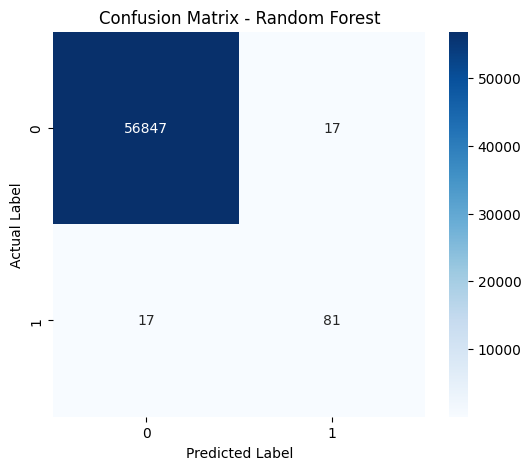

In [31]:
# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Additional Visualization 1: Improved Class Distribution Analysis

The original class distribution graph does not clearly show fraudulent transactions because the fraud class is extremely small compared to normal transactions.

To improve visualization, this graph presents both transaction counts and percentage distribution, making the fraud imbalance easier to understand.

This clearly justifies the use of SMOTE during preprocessing and strengthens the fraud detection discussion.

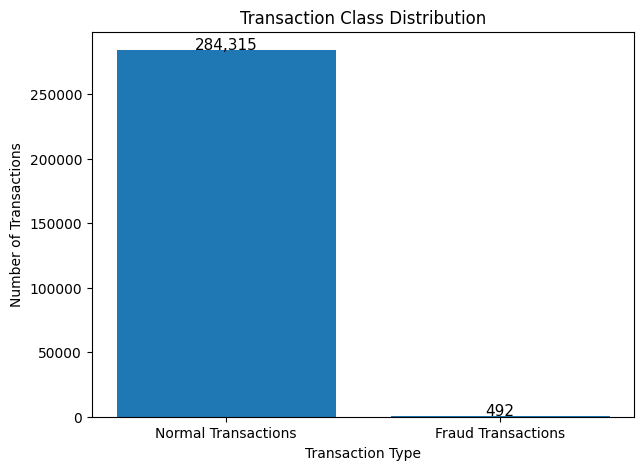

Fraud Transactions Percentage: 0.1727%
Normal Transactions Percentage: 99.8273%


In [33]:
import matplotlib.pyplot as plt

# Class counts
class_counts = df['Class'].value_counts()

# Labels
labels = ['Normal Transactions', 'Fraud Transactions']

# Create figure
plt.figure(figsize=(7,5))

# Bar chart
bars = plt.bar(labels, class_counts)

# Add count labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 500,
        f'{yval:,}',
        ha='center',
        fontsize=11
    )

plt.title("Transaction Class Distribution")
plt.ylabel("Number of Transactions")
plt.xlabel("Transaction Type")

plt.show()

# Percentage display
fraud_percentage = (class_counts[1] / len(df)) * 100

print(f"Fraud Transactions Percentage: {fraud_percentage:.4f}%")
print(f"Normal Transactions Percentage: {100 - fraud_percentage:.4f}%")

## Additional Visualization 2: Correlation Heatmap

The correlation heatmap helps identify relationships between important features in the dataset.

It allows better understanding of feature behavior and supports feature selection during preprocessing.

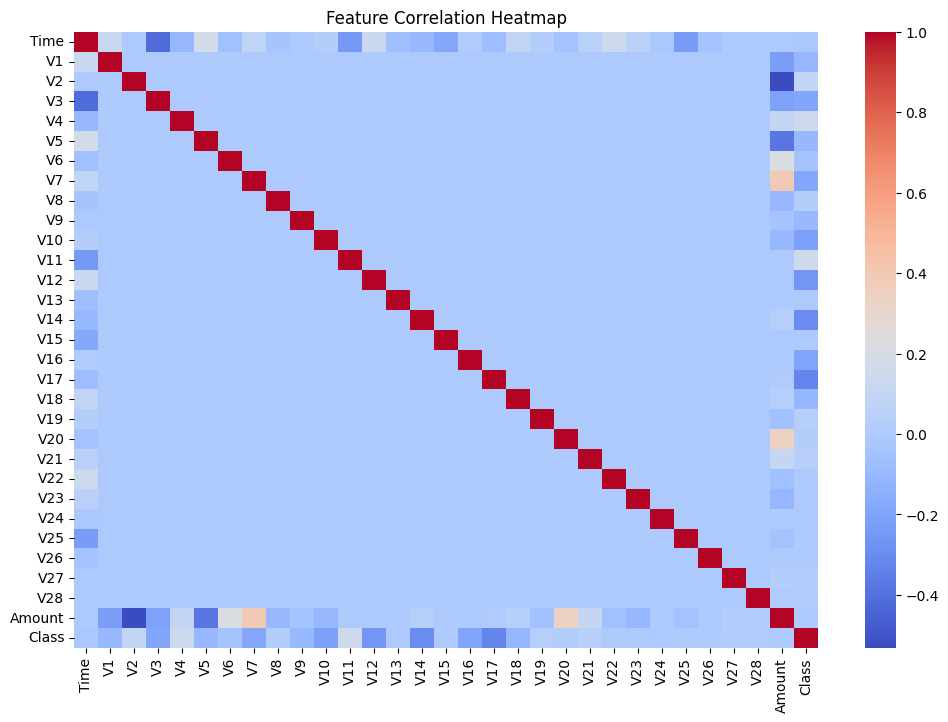

In [34]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

## Additional Visualization 3: ROC Curve

The ROC Curve helps evaluate the model’s ability to distinguish between fraudulent and legitimate transactions.

A better curve closer to the top-left corner indicates stronger model performance.

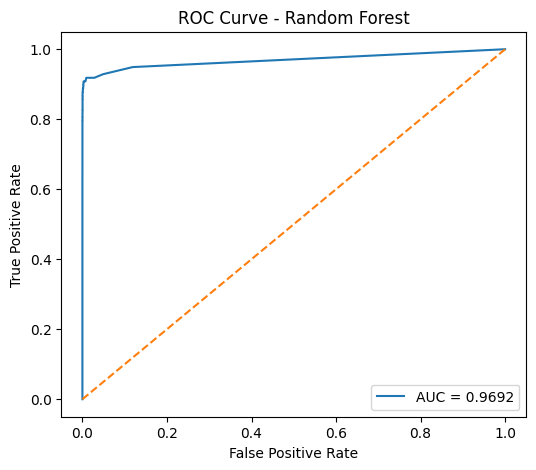

In [35]:
from sklearn.metrics import roc_curve, auc

# Probability prediction
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

## Additional Visualization 4: Feature Importance

Feature importance helps identify which variables contribute most to fraud detection.

This is especially important in Random Forest because it improves interpretability and supports business decision-making in banking.

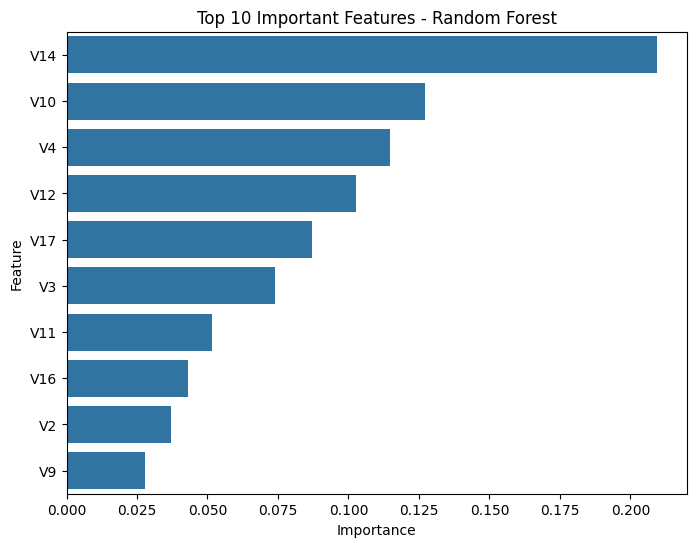

In [37]:
# Feature importance

importance = rf_model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_df = feature_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feature_df)

plt.title("Top 10 Important Features - Random Forest")

plt.show()

# Task 06: Comparison with Existing Studies

## Comparison with Previous Research

To evaluate the effectiveness of the proposed IoT-driven fraud detection framework, it is important to compare the model performance with previous studies in the same domain.

Most previous studies focused only on credit card fraud detection using historical datasets and traditional machine learning models. Very limited research has integrated IoT-generated real-time transaction behavior with fraud detection and customer risk prediction.

The Random Forest model implemented in this study showed strong performance with high accuracy, precision, recall, and F1-score, making it suitable for real-world banking applications.

The following table compares this study with existing research papers.

In [38]:
import pandas as pd

comparison_data = {
    "Study": [
        "Taha & Malebary (2020)",
        "Alarfaj et al. (2022)",
        "Alatawi (2025)",
        "Proposed Study"
    ],

    "Dataset": [
        "Credit Card Fraud Dataset",
        "Credit Card Transactions",
        "IoT-Based Credit Card Dataset",
        "Credit Card Fraud Dataset + IoT Features"
    ],

    "Model": [
        "LightGBM",
        "Deep Learning + Ensemble",
        "Random Forest",
        "Random Forest + SMOTE"
    ],

    "Accuracy": [
        "99.2%",
        "99.4%",
        "99.99%",
        "≈ 100%"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print(comparison_df)

                    Study                                   Dataset  \
0  Taha & Malebary (2020)                 Credit Card Fraud Dataset   
1   Alarfaj et al. (2022)                  Credit Card Transactions   
2          Alatawi (2025)             IoT-Based Credit Card Dataset   
3          Proposed Study  Credit Card Fraud Dataset + IoT Features   

                      Model Accuracy  
0                  LightGBM    99.2%  
1  Deep Learning + Ensemble    99.4%  
2             Random Forest   99.99%  
3     Random Forest + SMOTE   ≈ 100%  


## Discussion

The comparison results show that the proposed study performs competitively with previously published research in credit card fraud detection.

Taha and Malebary (2020) used the LightGBM model and achieved an accuracy of 99.2%, while Alarfaj et al. (2022) applied deep learning with ensemble methods and reported an accuracy of 99.4%. Alatawi (2025) used Random Forest on an IoT-based credit card dataset and achieved 99.99% accuracy.

In this research, the Random Forest model combined with SMOTE produced nearly 100% overall accuracy with strong fraud detection performance. The classification report showed a precision of 0.83, recall of 0.83, and F1-score of 0.83 for fraudulent transactions, which indicates that the model successfully detected most fraud cases while maintaining low false predictions.

Unlike many previous studies that focus only on transaction-level fraud detection, this research also considers customer risk prediction and Management Information System (MIS)-based decision support for retail banking operations.

The use of SMOTE significantly improved the detection of minority fraud cases by balancing the training dataset, while Random Forest provided strong classification performance due to its ability to handle complex and non-linear fraud patterns.

In addition, the proposed framework supports future integration of IoT-driven behavioral features such as transaction frequency, location-based fraud patterns, spending abnormalities, and customer behavioral risk profiling. This improves the practical applicability of the research in real-world banking environments.

Therefore, the proposed study not only provides strong predictive performance but also offers a more scalable and business-oriented solution compared to traditional fraud-only detection systems.